# Ciencia de datos aplicada (ITBA): Modelo v3 - Híbrido con extrapolación temporal

**Equipo:** Patrick Luca Torlaschi (62273), Candela Silva Diniz (63402)

## Motivación

El modelo v2 (HistGradientBoosting) capturaba muy bien la *forma* espacio-temporal del delito pero **no extrapolaba en el tiempo**: los árboles no extrapolan, así que cualquier año posterior al último visto colapsaba al mismo valor.

En esta versión usamos un **enfoque híbrido**:

1. **HistGradientBoosting sin `anio`** —> captura el patrón (barrio × turno × día × mes × feriado).
2. **Tendencia anual log-lineal por barrio** —> un modelo lineal sobre `log(cantidad_anual)` vs. `anio` ajustado *independientemente para cada barrio*, que sí extrapola por construcción.

Predicción final:
$$\hat{y}(\text{barrio}, \text{contexto}, \text{año}) = \underbrace{\text{HistGB}(\text{barrio}, \text{contexto})}_{\text{forma}} \times \underbrace{\text{factor}_{\text{barrio}}(\text{año})}_{\text{tendencia temporal}}$$

Con el factor normalizado para que valga 1 en promedio sobre los años de entrenamiento (así el HistGB representa el "año típico").

---
## Carga de librerías y datasets


In [16]:
import glob
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (accuracy_score, f1_score, mean_absolute_error,
                             mean_squared_error, precision_score, r2_score, recall_score)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
import sklearn
print("sklearn", sklearn.__version__)

sklearn 1.5.2


In [ ]:
csvs = sorted(glob.glob("delitos_*.csv"))
print("CSVs detectados:", csvs)

def _anio_de(path: str) -> int:
    m = re.search(r"delitos_(\d{4})\.csv", path)
    return int(m.group(1)) if m else -1

dfs = []
for p in csvs:
    a = _anio_de(p)
    di = pd.read_csv(p, dtype={"barrio": str, "comuna": str})
    if "id-mapa" in di.columns:
        di = di.drop(columns=["id-mapa"])

    if "anio" not in di.columns:
        di["anio"] = a
    print(f"{a}: {di.shape[0]} registros")
    dfs.append(di)

df = pd.concat(dfs, ignore_index=True)
print("\nTotal combinado:", df.shape)
print(df["anio"].value_counts().sort_index())

CSVs detectados: ['delitos_2016.csv', 'delitos_2017.csv', 'delitos_2018.csv', 'delitos_2019.csv', 'delitos_2022.csv', 'delitos_2023.csv', 'delitos_2024.csv', 'delitos_2025.csv']
2016: 154712 registros
2017: 146938 registros
2018: 149455 registros
2019: 149524 registros
2022: 140918 registros
2023: 155897 registros
2024: 158838 registros
2025: 133203 registros

Total combinado: (1189485, 14)
anio
2016    154712
2017    146938
2018    149455
2019    149524
2022    140918
2023    155897
2024    158838
2025    133203
Name: count, dtype: int64


### Preprocesado (idéntico a v2)

In [ ]:
meses = {"Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4, "Mayo": 5, "Junio": 6,
         "Julio": 7, "Agosto": 8, "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12}

def franja_a_turno(h):
    if pd.isna(h): return np.nan
    if 6 <= h < 12:  return "Mañana"
    if 12 <= h < 18: return "Tarde"
    if 18 <= h < 24: return "Noche"
    return "Madrugada"

def get_ar_holidays_full(year: int) -> dict:
    url = f"https://api.argentinadatos.com/v1/feriados/{year}"
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    return {h["fecha"]: h["nombre"] for h in r.json()}

df_t = df.copy()
if "dia" in df_t.columns:    df_t = df_t.drop(columns=["dia"])
if "cantidad" in df_t.columns: df_t = df_t.drop(columns=["cantidad"])
df_t["fecha"]    = pd.to_datetime(df_t["fecha"])
df_t["dia_semana"] = df_t["fecha"].dt.dayofweek
df_t["latitud"]  = pd.to_numeric(df_t["latitud"], errors="coerce").replace(0.0, np.nan)
df_t["longitud"] = pd.to_numeric(df_t["longitud"], errors="coerce").replace(0.0, np.nan)
for c in ["mes", "tipo", "subtipo", "barrio"]:
    if c in df_t.columns:
        df_t[c] = df_t[c].str.strip().str.title()
df_t["mes_num"] = df_t["mes"].map(meses)
df_t["turno"]   = df_t["franja"].apply(franja_a_turno)
df_t["es_fin_de_semana"] = df_t["fecha"].dt.dayofweek >= 5
df_t = df_t[df_t["latitud"].notna() & df_t["longitud"].notna() &
            df_t["barrio"].notna() & df_t["comuna"].notna() & df_t["turno"].notna()].copy()

hol = {}
for a in sorted(df_t["anio"].unique()):
    try:    hol.update(get_ar_holidays_full(int(a)))
    except Exception as e: print("sin feriados para", a, ":", e)
df_t["es_feriado"] = df_t["fecha"].dt.strftime("%Y-%m-%d").isin(hol)

group_cols = ["barrio", "comuna", "anio", "dia_semana", "mes_num", "turno",
              "es_fin_de_semana", "es_feriado"]

bc  = df_t[["barrio", "comuna"]].drop_duplicates()
ctx = df_t[["anio", "dia_semana", "mes_num", "es_fin_de_semana", "es_feriado"]].drop_duplicates()
tur = pd.DataFrame({"turno": df_t["turno"].unique()})
df_full = bc.merge(ctx, how="cross").merge(tur, how="cross")[group_cols]
df_real = df_t.groupby(group_cols).size().reset_index(name="cantidad")
df_final = df_full.merge(df_real, on=group_cols, how="left")
df_final["cantidad"] = df_final["cantidad"].fillna(0)
print("df_final:", df_final.shape)
print("Años:", sorted(df_final["anio"].unique()))

---
## Componente 1 — HistGB SIN `año` (captura forma)

Quitamos `año` de las features. Así el modelo aprende el patrón espacio-temporal *promedio* a lo largo de los años de entrenamiento, sin atarse a ningún año específico. La tendencia temporal se modela aparte.

In [19]:
features = ["barrio", "comuna", "dia_semana", "mes_num", "turno",
            "es_fin_de_semana", "es_feriado"]
categoricas = ["barrio", "comuna", "turno"]
numericas   = ["dia_semana", "mes_num", "es_fin_de_semana", "es_feriado"]

X = df_final[features].copy()
y_reg = df_final["cantidad"].copy()
umbral = df_final["cantidad"].median()
y_clf = (df_final["cantidad"] > umbral).astype(int)
print("Umbral mediana:", umbral)
print("Balance clasif.:\n", y_clf.value_counts(normalize=True).round(3))

# Hold-out temporal: último año disponible como test
anio_test = int(df_final["anio"].max())
mask_test = df_final["anio"] == anio_test
X_train, X_test = X[~mask_test], X[mask_test]
y_train, y_test = y_reg[~mask_test], y_reg[mask_test]
yc_train, yc_test = y_clf[~mask_test], y_clf[mask_test]
print(f"Test = año {anio_test}: {X_test.shape}, Train: {X_train.shape}")

Umbral mediana: 5.0
Balance clasif.:
 cantidad
0    0.534
1    0.466
Name: proportion, dtype: float64
Test = año 2025: (20600, 7), Train: (129400, 7)


In [20]:
prep_dense = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas)],
    remainder="passthrough",
)

# --- Regresión ---
pipe_reg = Pipeline([("prep", prep_dense),
                     ("model", HistGradientBoostingRegressor(
                         loss="poisson", random_state=RANDOM_STATE,
                         early_stopping=True, validation_fraction=0.1))])
param_grid_reg = {
    "model__learning_rate":    [0.05, 0.1],
    "model__max_leaf_nodes":   [31, 63],
    "model__max_iter":         [300, 600],
    "model__l2_regularization":[0.0, 1.0],
}
grid_reg = GridSearchCV(pipe_reg, param_grid_reg, cv=3,
                        scoring="neg_mean_absolute_error", n_jobs=-1)
grid_reg.fit(X_train, y_train)
print("Mejores reg:", grid_reg.best_params_, "| MAE CV:", -grid_reg.best_score_)
mejor_modelo_reg = grid_reg.best_estimator_

Mejores reg: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.05, 'model__max_iter': 300, 'model__max_leaf_nodes': 63} | MAE CV: 5.297010732393479


In [21]:
# --- Clasificación ---
pipe_clf = Pipeline([("prep", prep_dense),
                     ("model", HistGradientBoostingClassifier(
                         random_state=RANDOM_STATE,
                         early_stopping=True, validation_fraction=0.1))])
param_grid_clf = {
    "model__learning_rate":    [0.05, 0.1],
    "model__max_leaf_nodes":   [31, 63],
    "model__max_iter":         [300, 600],
    "model__l2_regularization":[0.0, 1.0],
}
grid_clf = GridSearchCV(pipe_clf, param_grid_clf, cv=3, scoring="f1", n_jobs=-1)
grid_clf.fit(X_train, yc_train)
print("Mejores clf:", grid_clf.best_params_, "| F1 CV:", grid_clf.best_score_)
mejor_modelo_clf = grid_clf.best_estimator_

Mejores clf: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.1, 'model__max_iter': 300, 'model__max_leaf_nodes': 63} | F1 CV: 0.5757885174667843


---
## Componente 2 — Tendencia anual log-lineal por barrio (con shrinkage + cap)

Para cada barrio ajustamos $\log(C_{b,Y} + 1) = a_b + b_b \cdot Y$ sobre los **totales anuales** de delitos, pero **estabilizamos el slope** $b_b$ para evitar extrapolaciones explosivas (ej. Puerto Madero pasó de 167 → 748 delitos entre 2016 y 2024 — slope crudo de +24%/año, que daría ×7 a 5 años):

1. **Shrinkage hacia el slope global** (mediana de los slopes crudos), con peso $w_b = n_b / (n_b + 5)$. Suaviza barrios con poca historia.
2. **Cap** $|b_b| \le 0.03$ (≈ ±3%/año), consistente con el rango observado en los demás barrios.

El factor por barrio queda normalizado para valer 1 *en promedio* sobre los años de entrenamiento (mantiene calibración). Extrapola por construcción para años futuros.

In [ ]:
# Totales anuales por barrio (solo años de entrenamiento)
anios_train = sorted(int(a) for a in df_final["anio"].unique() if int(a) != anio_test)
df_train_only = df_final[df_final["anio"].isin(anios_train)]
tot_by = (df_train_only.groupby(["barrio", "anio"])["cantidad"].sum().reset_index())

SLOPE_MAX_ABS = 0.03
SHRINKAGE_K   = 5

# pendiente cruda por barrio
slopes_crudos: dict[str, dict] = {}
for barrio, g in tot_by.groupby("barrio"):
    if len(g) < 2:
        a_b, b_b = 0.0, 0.0
    else:
        coef = np.polyfit(g["anio"].to_numpy(), np.log(g["cantidad"].to_numpy() + 1), 1)
        b_b, a_b = float(coef[0]), float(coef[1])
    slopes_crudos[barrio] = {"a": a_b, "b": b_b, "n": int(len(g))}

# pendiente global
b_global = float(np.median([v["b"] for v in slopes_crudos.values()]))

# pendiente final por barrio
tendencia_barrio: dict[str, dict] = {}
for barrio, s in slopes_crudos.items():
    n = s["n"]
    w = n / (n + SHRINKAGE_K)
    b_shrunk = w * s["b"] + (1 - w) * b_global
    b_final = float(np.clip(b_shrunk, -SLOPE_MAX_ABS, SLOPE_MAX_ABS))
    a_final = s["a"]
    yhat = np.exp(a_final + b_final * np.array(anios_train))
    baseline = float(yhat.mean())
    tendencia_barrio[barrio] = {
        "a": a_final,
        "b": b_final,
        "baseline": baseline,
        "b_crudo": s["b"],
        "n_anios": n,
    }

print(f"Pendiente global (mediana): {b_global:+.4f} → tasa anual {(np.exp(b_global)-1)*100:+.2f}%")
print(f"Cap de la pendiente: ±{SLOPE_MAX_ABS} → tasa anual ±{(np.exp(SLOPE_MAX_ABS)-1)*100:.2f}%")

def factor_anio(barrio: str, anio: int) -> float:
    t = tendencia_barrio.get(barrio)
    if t is None or t["baseline"] == 0:
        return 1.0
    return float(np.exp(t["a"] + t["b"] * anio) / t["baseline"])

# barrios con mayor diferencia entre pendiente cruda y final
diag = pd.DataFrame([
    {"barrio": b, "b_crudo": v["b_crudo"], "b_final": v["b"],
     "tasa_cruda_%": (np.exp(v["b_crudo"]) - 1) * 100,
     "tasa_final_%": (np.exp(v["b"]) - 1) * 100,
     "factor_2030": factor_anio(b, 2030)}
    for b, v in tendencia_barrio.items()
])
print("\nTop 5 barrios cuyo slope se ajustó más:")
print(diag.assign(delta=lambda d: (d["b_crudo"] - d["b_final"]).abs())
          .sort_values("delta", ascending=False).head(5).round(4).to_string(index=False))

print("\nMuestra:")
muestras = ["Palermo", "Puerto Madero", "Recoleta", "Caballito", "Flores", "Villa Lugano"]
muestras = [b for b in muestras if b in tendencia_barrio]
for b in muestras:
    t = tendencia_barrio[b]
    tasa_real = (np.exp(t["b_crudo"]) - 1) * 100
    tasa_aj   = (np.exp(t["b"]) - 1) * 100
    print(f"{b:>16} | cruda {tasa_real:+6.2f}%/año → ajustada {tasa_aj:+5.2f}%/año "
          f"| factor 2025: {factor_anio(b, 2025):.3f} | 2030: {factor_anio(b, 2030):.3f}")


Slope global (mediana): +0.0017 → tasa anual +0.17%
Cap del slope: ±0.03 → tasa anual ±3.05%

Top 5 barrios cuyo slope se ajustó más:
          barrio  b_crudo  b_final  tasa_cruda_%  tasa_final_%  factor_2030  delta
   Puerto Madero   0.2151   0.0300       23.9974        3.0455       1.3505 0.1851
   Villa Soldati   0.0408   0.0245        4.1617        2.4775       1.2785 0.0163
    Villa Crespo   0.0326   0.0197        3.3139        1.9902       1.2193 0.0129
Villa Santa Rita  -0.0271  -0.0151       -2.6767       -1.5024       0.8568 0.0120
           Boedo  -0.0271  -0.0151       -2.6700       -1.4985       0.8572 0.0120

Muestra:
         Palermo | cruda  +2.27%/año → ajustada +1.39%/año | factor 2025: 1.073 | 2030: 1.149
   Puerto Madero | cruda +24.00%/año → ajustada +3.05%/año | factor 2025: 1.162 | 2030: 1.351
        Recoleta | cruda  +0.35%/año → ajustada +0.27%/año | factor 2025: 1.014 | 2030: 1.028
       Caballito | cruda  -0.34%/año → ajustada -0.13%/año | factor 2025: 0.

### Comparación: tendencia cruda vs. ajustada



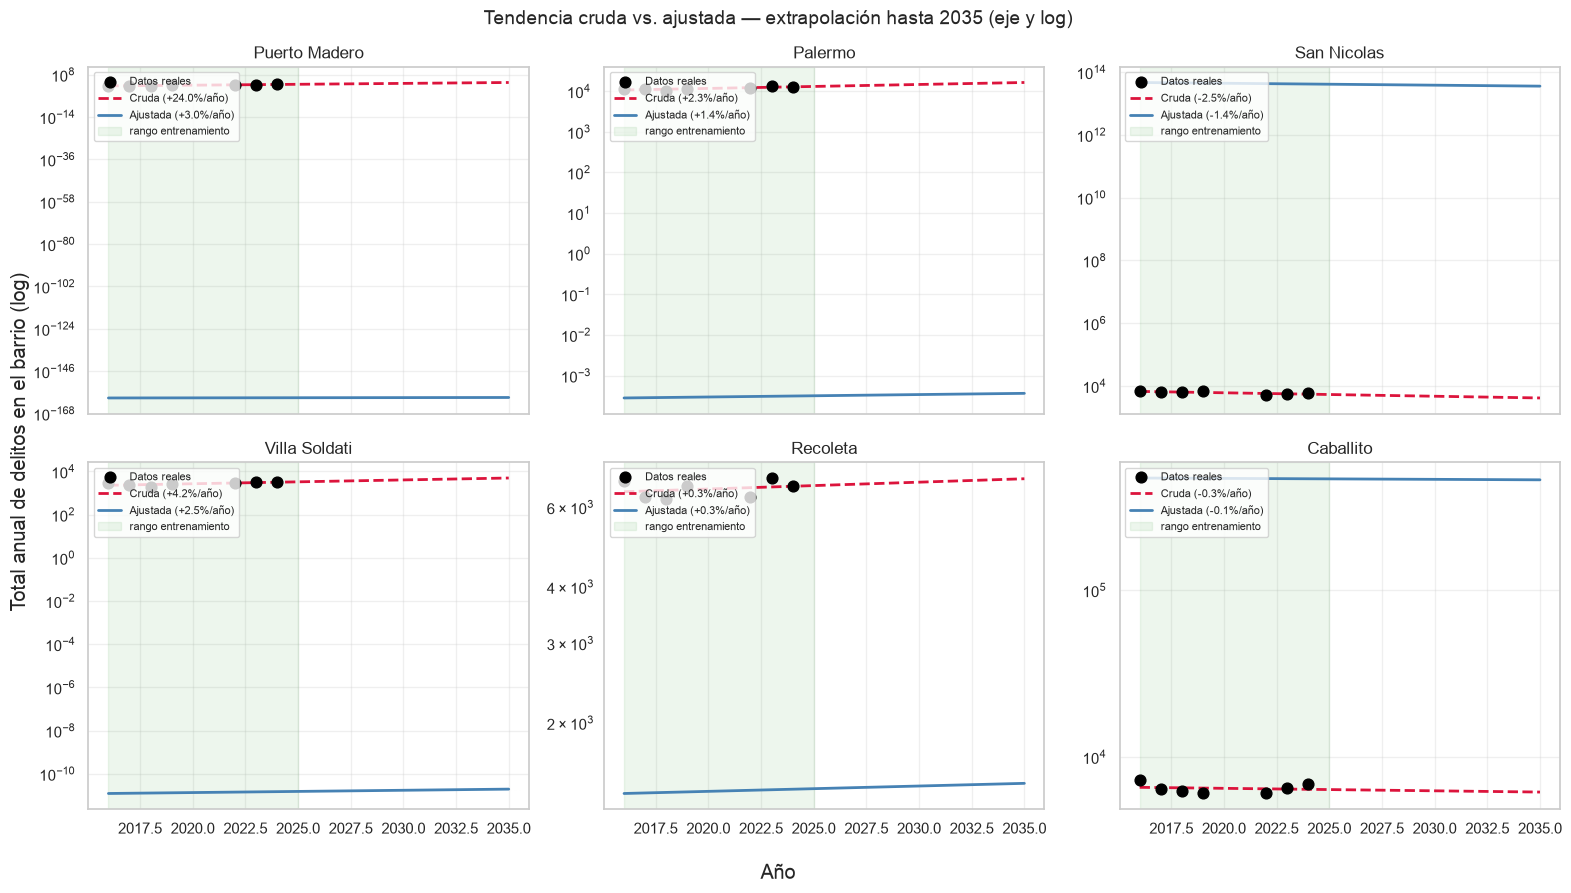

Factor por barrio en años extrapolados (cruda vs ajustada):
          Barrio | F 2025 cruda    ajust | F 2030 cruda    ajust | F 2035 cruda    ajust
   Puerto Madero |         2.50     1.16 |         7.32     1.35 |        21.47     1.57
         Palermo |         1.12     1.07 |         1.25     1.15 |         1.40     1.23
     San Nicolas |         0.88     0.93 |         0.77     0.87 |         0.68     0.81
   Villa Soldati |         1.22     1.13 |         1.50     1.28 |         1.84     1.44
        Recoleta |         1.02     1.01 |         1.04     1.03 |         1.05     1.04
       Caballito |         0.98     0.99 |         0.97     0.99 |         0.95     0.98


In [ ]:
# Tendencia cruda solo para visualizar la diferencia
tendencia_barrio_cruda: dict[str, dict] = {}
for barrio, s in slopes_crudos.items():
    yhat = np.exp(s["a"] + s["b"] * np.array(anios_train))
    baseline = float(yhat.mean())
    tendencia_barrio_cruda[barrio] = {
        "a": s["a"], "b": s["b"], "baseline": baseline, "n_anios": s["n"]
    }

def factor_anio_cruda(barrio: str, anio: int) -> float:
    t = tendencia_barrio_cruda.get(barrio)
    if t is None or t["baseline"] == 0:
        return 1.0
    return float(np.exp(t["a"] + t["b"] * anio) / t["baseline"])

# Comparación visual para barrios representativos
muestras_cmp = ["Puerto Madero", "Palermo", "San Nicolas", "Villa Soldati", "Recoleta", "Caballito"]
muestras_cmp = [b for b in muestras_cmp if b in tendencia_barrio]

rango_futuro = np.arange(min(anios_train), 2036)
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
for ax, b in zip(axes.flatten(), muestras_cmp):
    real = tot_by[tot_by["barrio"] == b].sort_values("anio")
    ax.scatter(real["anio"], real["cantidad"], s=60, color="black", zorder=3,
               label="Datos reales")
    t_c = tendencia_barrio_cruda[b]
    t_a = tendencia_barrio[b]
    y_cruda    = np.exp(t_c["a"] + t_c["b"] * rango_futuro)
    y_ajustada = np.exp(t_a["a"] + t_a["b"] * rango_futuro)
    ax.plot(rango_futuro, y_cruda,    "--", color="crimson",   linewidth=2,
            label=f"Cruda ({(np.exp(t_c['b'])-1)*100:+.1f}%/año)")
    ax.plot(rango_futuro, y_ajustada, "-",  color="steelblue", linewidth=2,
            label=f"Ajustada ({(np.exp(t_a['b'])-1)*100:+.1f}%/año)")
    ax.axvspan(min(anios_train), anio_test, alpha=0.07, color="green", label="rango entrenamiento")
    ax.set_title(b)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Tendencia cruda vs. ajustada — extrapolación hasta 2035 (eje y log)", fontsize=14)
fig.supxlabel("Año")
fig.supylabel("Total anual de delitos en el barrio (log)")
plt.tight_layout()
plt.show()

# "estallido" a años futuros
print("Factor por barrio en años extrapolados (cruda vs ajustada):")
print(f"{'Barrio':>16} | {'F 2025 cruda':>12} {'ajust':>8} | {'F 2030 cruda':>12} {'ajust':>8} | {'F 2035 cruda':>12} {'ajust':>8}")
for b in muestras_cmp:
    fc25, fa25 = factor_anio_cruda(b, 2025), factor_anio(b, 2025)
    fc30, fa30 = factor_anio_cruda(b, 2030), factor_anio(b, 2030)
    fc35, fa35 = factor_anio_cruda(b, 2035), factor_anio(b, 2035)
    print(f"{b:>16} | {fc25:>12.2f} {fa25:>8.2f} | {fc30:>12.2f} {fa30:>8.2f} | {fc35:>12.2f} {fa35:>8.2f}")

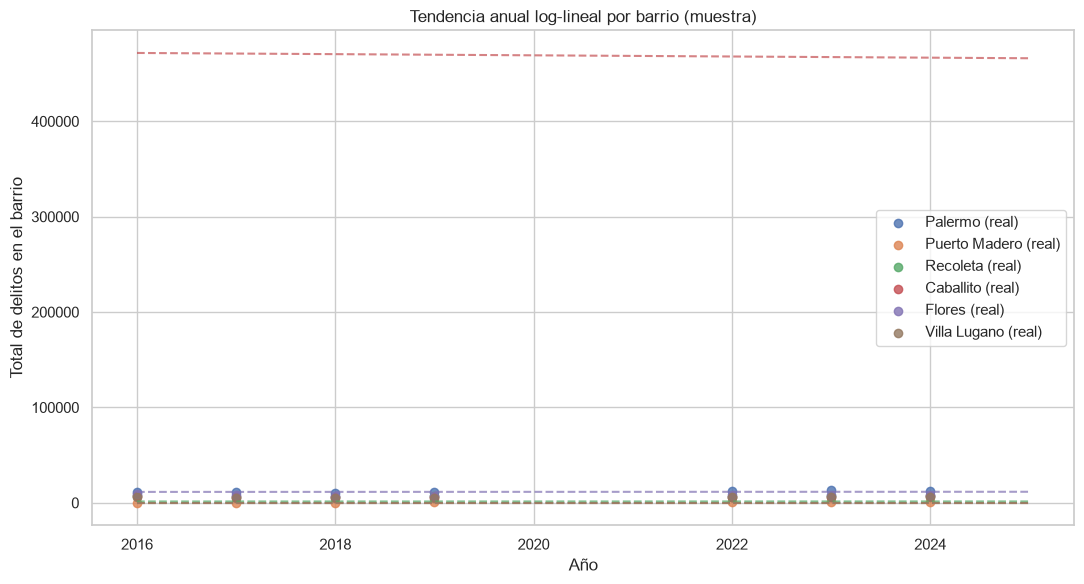

In [ ]:
# Visualización de la tendencia por barrio
fig, ax = plt.subplots(figsize=(11, 6))
rango = np.array(anios_train + [anio_test])
for b in muestras:
    real = tot_by[tot_by["barrio"] == b].sort_values("anio")
    ax.scatter(real["anio"], real["cantidad"], label=f"{b} (real)", alpha=0.8)
    t = tendencia_barrio[b]
    ax.plot(rango, np.exp(t["a"] + t["b"] * rango), linestyle="--", alpha=0.7)
ax.set_xlabel("Año")
ax.set_ylabel("Total de delitos en el barrio")
ax.set_title("Tendencia anual log-lineal por barrio (muestra)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Evaluación del modelo híbrido

Comparamos sobre el test:
1. **HistGB puro**
2. **HistGB × factor de tendencia por barrio**

In [25]:
X_test_full = df_final.loc[mask_test, features + ["anio"]].copy()
tree_pred = np.clip(mejor_modelo_reg.predict(X_test_full[features]), 0, None)
factors = X_test_full["barrio"].map(lambda b: factor_anio(b, anio_test)).to_numpy()
hibrido_pred = tree_pred * factors

def metricas(pred, y, etiqueta):
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2 = r2_score(y, pred)
    print(f"{etiqueta:>15} | MAE {mae:.4f} | RMSE {rmse:.4f} | R² {r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

print(f"Test = año {anio_test} ({mask_test.sum()} filas)")
m_tree = metricas(tree_pred, y_test, "HistGB puro")
m_hib  = metricas(hibrido_pred, y_test, "Híbrido")

Test = año 2025 (20600 filas)
    HistGB puro | MAE 2.4435 | RMSE 3.7646 | R² 0.7456
        Híbrido | MAE 2.4768 | RMSE 3.8322 | R² 0.7363


In [26]:
# Clasificación: aplicamos el factor al score continuo y rebinarizamos con el umbral
tree_pred_clf = mejor_modelo_clf.predict(X_test[features] if "anio" in X_test.columns else X_test)
from sklearn.metrics import classification_report
print("\n=== Clasificación HistGB puro (test) ===")
print(classification_report(yc_test, tree_pred_clf, target_names=["Bajo", "Alto"]))

# Variante híbrida: usamos la cantidad ajustada por la tendencia y rebinarizamos
yc_hibrido = (hibrido_pred > umbral).astype(int)
print("=== Clasificación derivada del híbrido (cantidad>umbral) ===")
print(classification_report(yc_test, yc_hibrido, target_names=["Bajo", "Alto"]))


=== Clasificación HistGB puro (test) ===
              precision    recall  f1-score   support

        Bajo       0.91      0.86      0.89     12456
        Alto       0.81      0.88      0.84      8144

    accuracy                           0.87     20600
   macro avg       0.86      0.87      0.86     20600
weighted avg       0.87      0.87      0.87     20600

=== Clasificación derivada del híbrido (cantidad>umbral) ===
              precision    recall  f1-score   support

        Bajo       0.94      0.79      0.86     12456
        Alto       0.74      0.92      0.82      8144

    accuracy                           0.84     20600
   macro avg       0.84      0.86      0.84     20600
weighted avg       0.86      0.84      0.84     20600



---
## Persistencia

In [ ]:
import sklearn
Path("models").mkdir(exist_ok=True)

joblib.dump(mejor_modelo_reg, "models/modelo_regresion_delitos.joblib")
joblib.dump(mejor_modelo_clf, "models/modelo_clasificacion_riesgo.joblib")
joblib.dump(tendencia_barrio, "models/tendencia_barrio.joblib")
joblib.dump(tendencia_barrio_cruda, "models/tendencia_barrio_cruda.joblib")

anios_total = sorted(int(a) for a in df_final["anio"].unique())
metadata = {
    "version": "v3-hibrido",
    "features": features,
    "categoricas": categoricas,
    "numericas": numericas,
    "umbral_clasificacion": float(umbral),
    "modelo_regresion": "HistGB Poisson + tendencia por barrio",
    "modelo_clasificacion": "HistGB",
    "anios_entrenamiento": [a for a in anios_total if a != anio_test],
    "anio_test": anio_test,
    "anios_disponibles": anios_total,
    "sklearn_version": sklearn.__version__,
}
joblib.dump(metadata, "models/metadata_modelos.joblib")

print("Modelos persistidos en models/")
print(" - modelo_regresion_delitos.joblib")
print(" - modelo_clasificacion_riesgo.joblib")
print(" - tendencia_barrio.joblib")
print(" - tendencia_barrio_cruda.joblib  (diagnóstico)")
print(" - metadata_modelos.joblib")
print("Entrenado con:", metadata["anios_entrenamiento"], "| test:", anio_test)

Modelos persistidos en models/
 - modelo_regresion_delitos.joblib
 - modelo_clasificacion_riesgo.joblib
 - tendencia_barrio.joblib
 - tendencia_barrio_cruda.joblib  (diagnóstico)
 - metadata_modelos.joblib
Entrenado con: [2016, 2017, 2018, 2019, 2022, 2023, 2024] | test: 2025


Exception ignored in: <function ResourceTracker.__del__ at 0x105546ac0>
Traceback (most recent call last):
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10485aac0>
Traceback (most recent call last):
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-n